There are some global bounds on what variables can realistically be (e.g. even under climate change, mean temperatures shouldn't be 500K anywhere globally!) but we also want to evaluate whether output is within plausible ranges for a given location and time of year. E.g., lots of places are 25C, but 25C in Antarctica in the winter should raise eyebrows. Here we construct plausible ranges for each day of year, based on the variability in the coarse GCM modeled changes relative to the historical, and variability in observations.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import icechunk
import matplotlib.pyplot as plt
import zarr

from srm import catalog
from srm.qaqc import calculate_reasonable_bounds_doy
from srm.utils import open_icechunk

## Get data

In [2]:
path_output = (
    "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
    # "s3://carbonplan-scratch/srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/"
)
path_qaqc = "/scratch/synced/qa_plots/plausible_value_check/"
branch = "v0.10.0"  # "qa-qc-downscaling-step/vtest01"  #


var = "tasmin"
scenario = "ssp245"
ens = "008"
spatial_subset = False

In [3]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",  # "carbonplan-scratch",
    # "srm/output/qa/CESM2-WACCM-ERA5-lat-35.0to-22.0_lon16.0to33.0.icechunk/",
    prefix="output/production/CESM2-WACCM-ERA5-global.icechunk/",
    region="us-west-2",
)
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
# print(root.tree())

{'v0.7.0', 'main', 'v0.8.0', 'v0.10.0'}
/
├── debiased_coarse
│   ├── g6_1p5k
│   │   ├── dtr
│   │   │   └── 003
│   │   │       ├── dtr (25568, 192, 288) float32
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       └── time (25568,) int64
│   │   ├── hurs
│   │   │   └── 003
│   │   │       ├── hurs (25568, 192, 288) float32
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       └── time (25568,) int64
│   │   ├── pr
│   │   │   └── 003
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       ├── pr (25568, 192, 288) float32
│   │   │       └── time (25568,) int64
│   │   ├── rsds
│   │   │   └── 003
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,) float64
│   │   │       ├── rsds (25568, 192, 288) float32
│   │   │       └── time (25568,) int64
│   │   ├── tas
│   │   │   └── 003
│   │   │       ├── lat (192,) float64
│   │   │       ├── lon (288,

In [4]:
debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)

raw_scenario = catalog.get("CESM2-WACCM").to_xarray()[scenario][var].sel(ensemble_member=ens)
raw_historical = catalog.get("CESM2-WACCM").to_xarray()["historical"][var]

if spatial_subset:
    obs_fine_subset = obs_fine.sel(lat=slice(-35, -22), lon=slice(16, 33))
    raw_scenario_subset = raw_scenario.sel(lat=slice(-35, -22), lon=slice(16, 33)).load()
    raw_historical_subset = raw_historical.sel(lat=slice(-35, -22), lon=slice(16, 33)).load()
else:
    obs_fine_subset = obs_fine
    raw_scenario_subset = raw_scenario
    raw_historical_subset = raw_historical

# Calculate bounds

In [8]:
low_bound, high_bound = calculate_reasonable_bounds_doy(
    raw_scenario_subset=raw_scenario_subset,
    raw_historical_subset=raw_historical_subset,
    obs_fine_subset=obs_fine_subset,
)

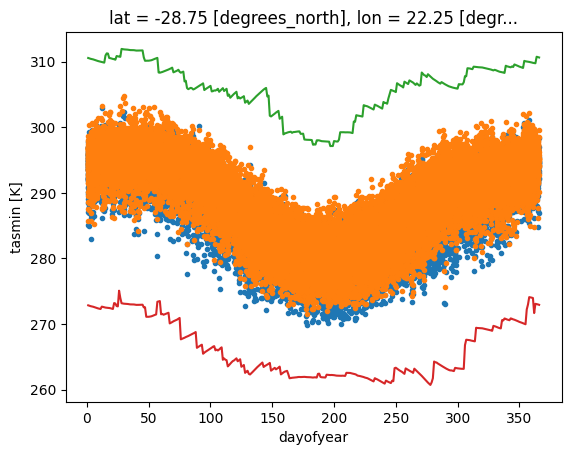

In [9]:
ilat = -28.75
ilon = 22.25
plt.plot(
    debiased_downscaled["time.dayofyear"],
    debiased_downscaled.sel(lat=ilat, lon=ilon, method="nearest"),
    ".",
)
plt.plot(
    raw_scenario_subset["time.dayofyear"],
    (raw_scenario_subset.sel(lat=ilat, lon=ilon, method="nearest")),
    ".",
)
(high_bound.sel(lat=ilat, lon=ilon, method="nearest")).plot()
(low_bound.sel(lat=ilat, lon=ilon, method="nearest")).plot()

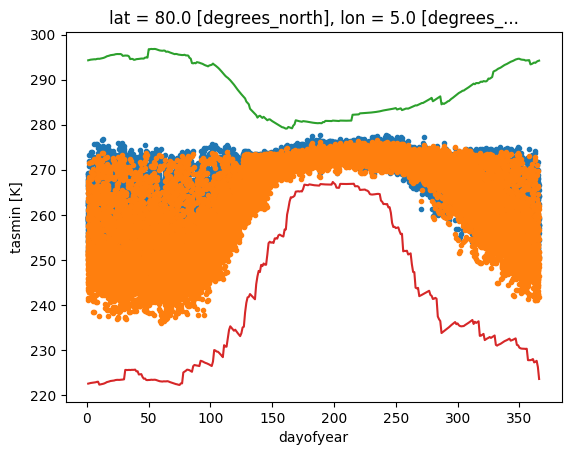

In [10]:
ilat = 80
ilon = 5
plt.plot(
    debiased_downscaled["time.dayofyear"],
    debiased_downscaled.sel(lat=ilat, lon=ilon, method="nearest"),
    ".",
)
plt.plot(
    raw_scenario_subset["time.dayofyear"],
    (raw_scenario_subset.sel(lat=ilat, lon=ilon, method="nearest")),
    ".",
)
(high_bound.sel(lat=ilat, lon=ilon, method="nearest")).plot()
(low_bound.sel(lat=ilat, lon=ilon, method="nearest")).plot()

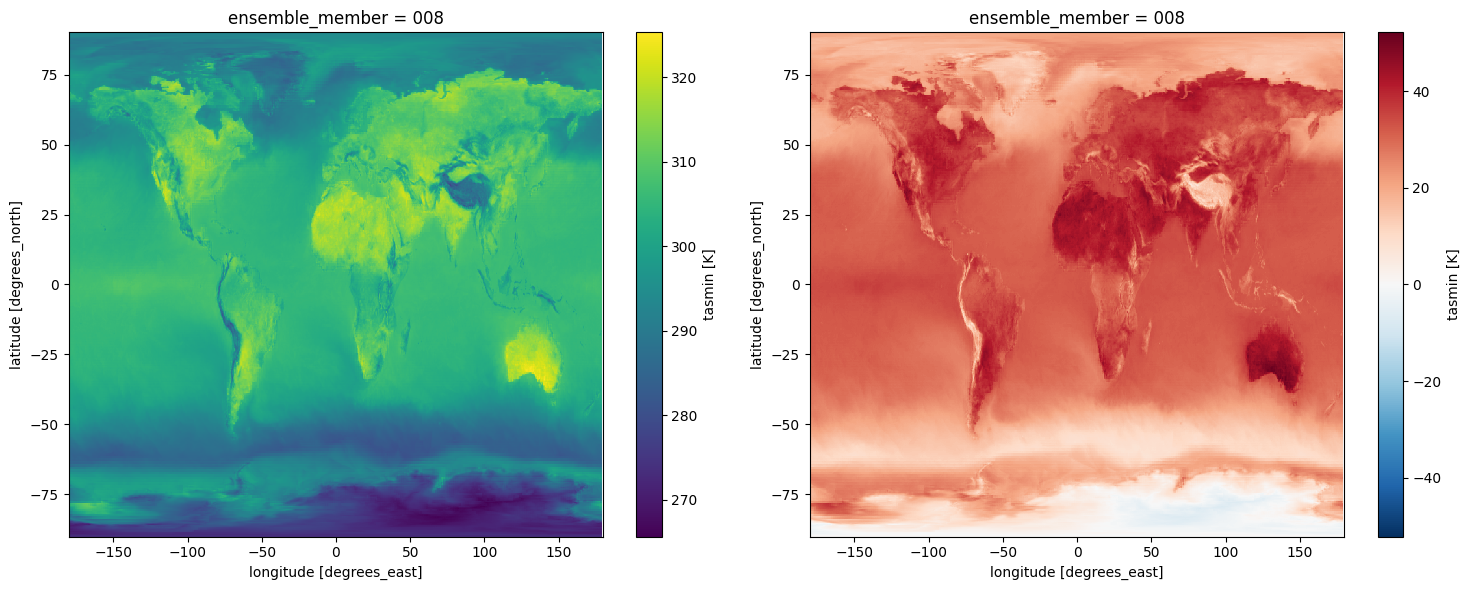

In [11]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
(high_bound.max(dim="dayofyear")).plot()
plt.subplot(1, 2, 2)
(high_bound.max(dim="dayofyear") - 273.15).plot(label="Celsius")
plt.tight_layout()

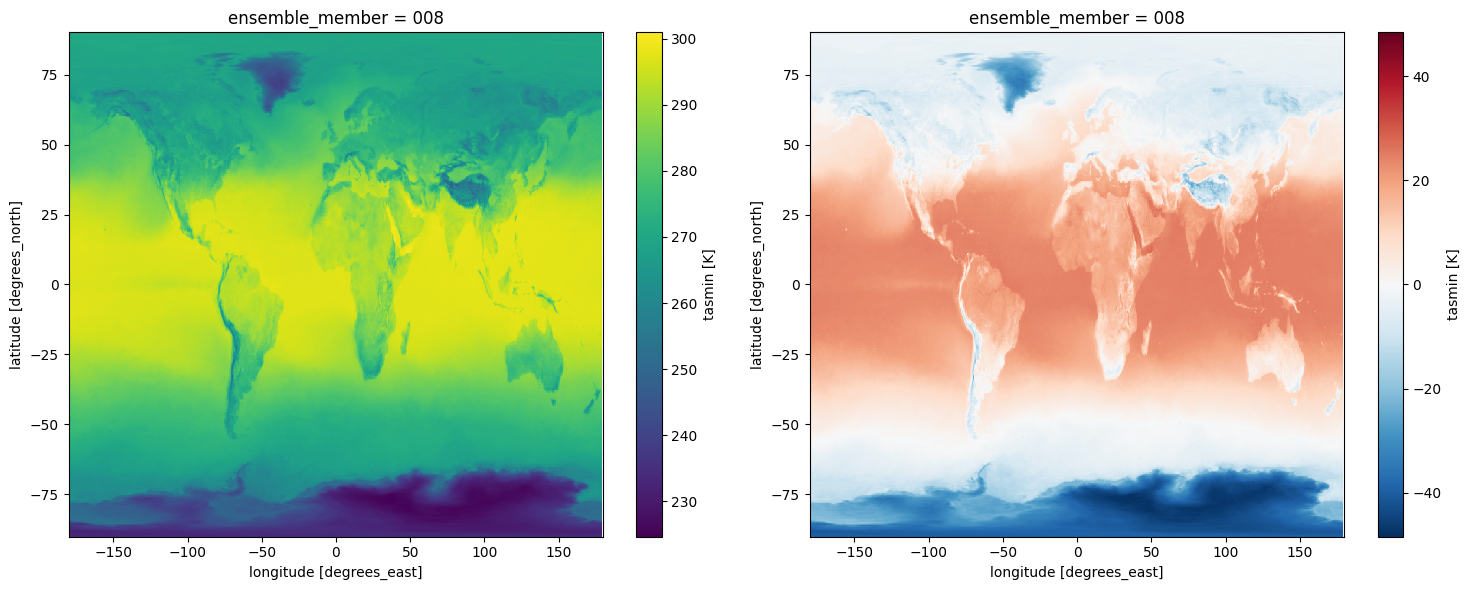

In [12]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
(low_bound.max(dim="dayofyear")).plot()
plt.subplot(1, 2, 2)
(low_bound.max(dim="dayofyear") - 273.15).plot(label="Celsius")
plt.tight_layout()

# Calculate values in bounds

In [13]:
high_bound_generous = high_bound + 1
low_bound_generous = low_bound - 1

In [14]:
# Very slow step
doy = debiased_downscaled["time.dayofyear"]
too_high = (debiased_downscaled > high_bound_generous.sel(dayofyear=doy)).mean(dim="time").compute()
too_low = (debiased_downscaled < low_bound_generous.sel(dayofyear=doy)).mean(dim="time").compute()

In [15]:
# This is very slow too
# too_high_delta = (debiased_downscaled - high_bound.sel(dayofyear=doy))
# too_high_delta_max = too_high_delta.where(too_high).max(dim="time").compute()
# too_low_delta = (debiased_downscaled - low_bound.sel(dayofyear=doy))
# too_low_delta_min = too_low_delta.where(too_low).min(dim="time").compute()

In [23]:
import pandas as pd


def print_frac_implausible(
    too_high, too_low, variable=None, scenario=None, ensemble_member=None, log_path=None
):
    frac_area_too_high = (too_high > 0).mean(dim=["lat", "lon"]).values
    frac_area_too_low = (too_low > 0).mean(dim=["lat", "lon"]).values
    print("Fraction of area too high: " + str(frac_area_too_high))
    print("Fraction of area too low: " + str(frac_area_too_low))

    if log_path is not None:
        df = pd.DataFrame(
            [
                {
                    "variable": variable,
                    "scenario": scenario,
                    "ensemble_member": ensemble_member,
                    "metric": "frac_area_too_high",
                    "value": frac_area_too_high,
                },
                {
                    "variable": variable,
                    "scenario": scenario,
                    "ensemble_member": ensemble_member,
                    "metric": "frac_area_too_low",
                    "value": frac_area_too_low,
                },
            ]
        )
        df.to_csv(log_path, mode="w", index=False)

In [24]:
print_frac_implausible(
    too_high,
    too_low,
    variable=var,
    scenario=scenario,
    ensemble_member=ens,
    log_path=path_qaqc + "area_out_of_range_frac_" + var + "_" + scenario + "_" + ens + ".csv",
)

Fraction of area too high: 0.005254083834180922
Fraction of area too low: 0.009056672830944676


# Plot reasonable checks

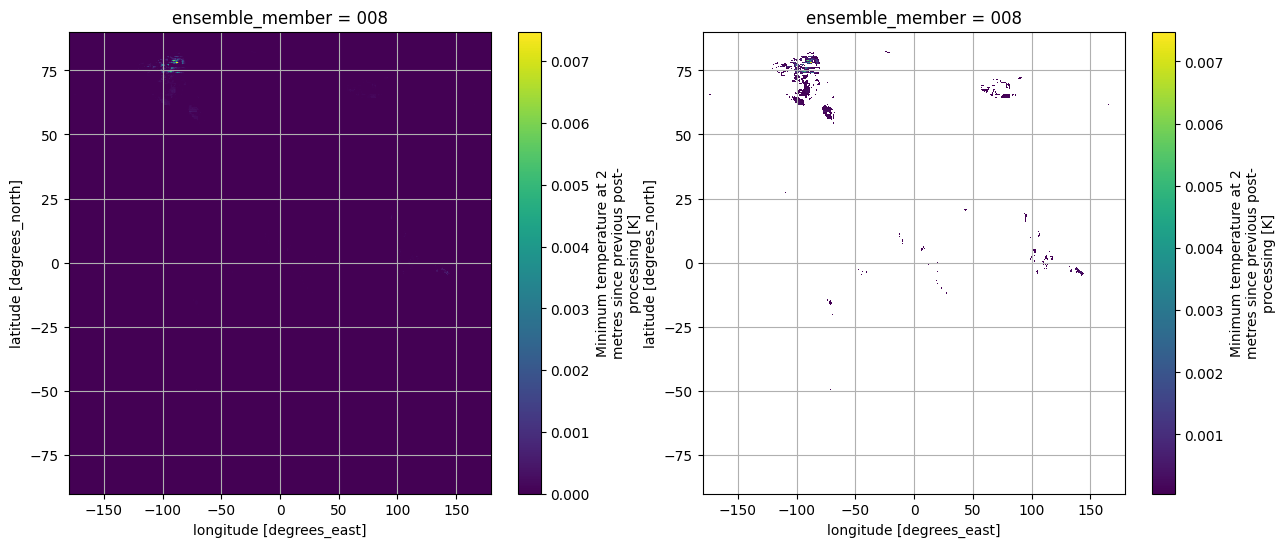

In [25]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
too_high.plot()
plt.grid()
plt.subplot(1, 2, 2)
too_high.where(too_high > 0).plot()
plt.grid()

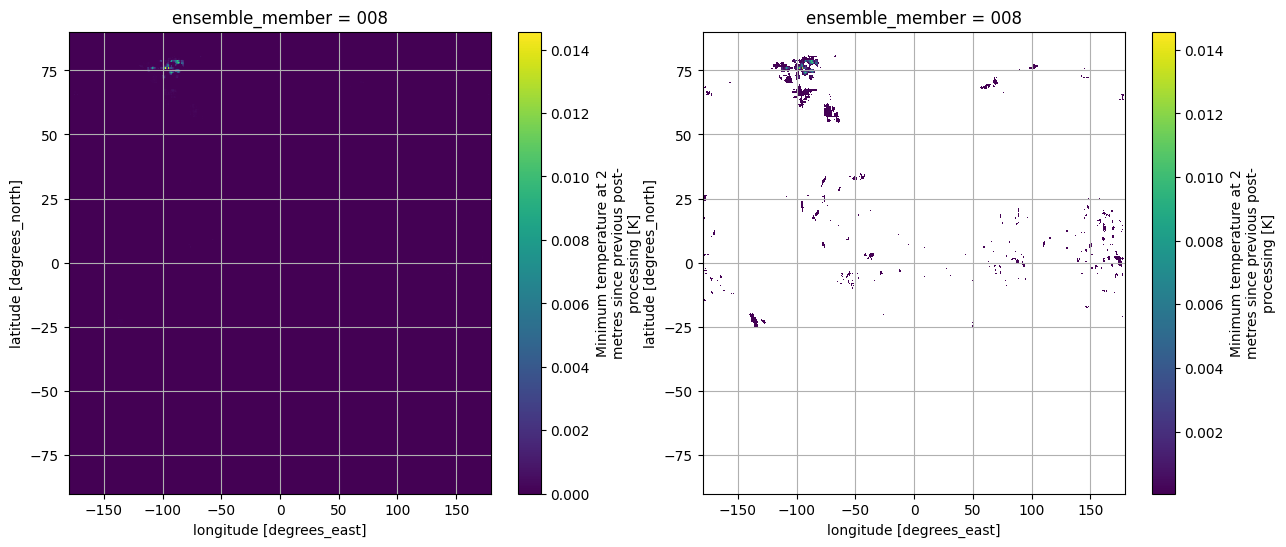

In [26]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
too_low.plot()
plt.grid()
plt.subplot(1, 2, 2)
too_low.where(too_low > 0).plot()
plt.grid()

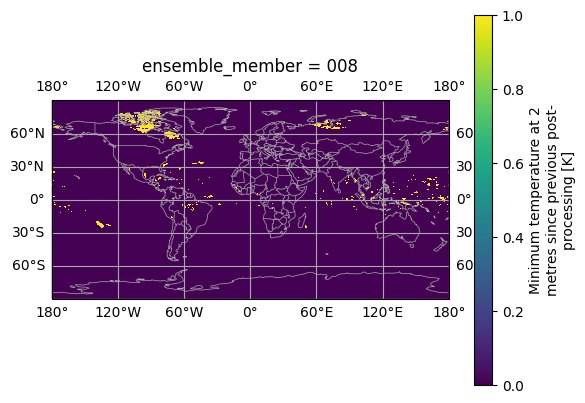

In [27]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="darkgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="darkgray")

((too_high + too_low) > 0).plot(ax=ax, transform=ccrs.PlateCarree(), label="Outside bounds")

ax.gridlines(draw_labels=True, color="darkgray")
plt.savefig(path_qaqc + "map_out_of_range_" + var + "_" + scenario + "_" + ens + ".png")

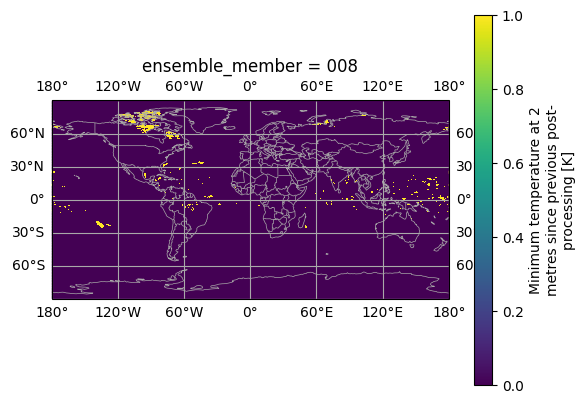

In [32]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="darkgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="darkgray")

(too_low > 0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    label="How outside bounds",
)

ax.gridlines(draw_labels=True, color="darkgray")
plt.savefig(path_qaqc + "map_min_out_of_range_" + var + "_" + scenario + "_" + ens + ".png")

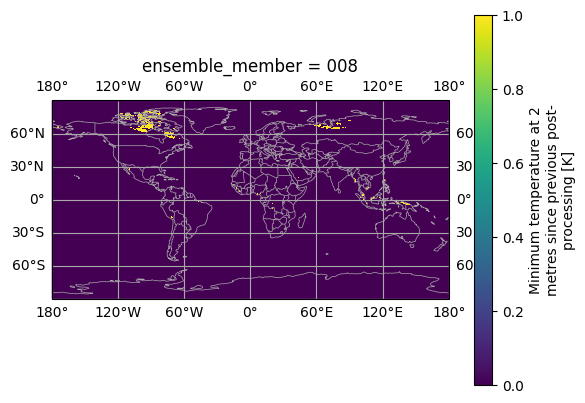

In [33]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="darkgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="darkgray")

(too_high > 0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    label="How outside bounds",
)

ax.gridlines(draw_labels=True, color="darkgray")
plt.savefig(path_qaqc + "map_max_out_of_range_" + var + "_" + scenario + "_" + ens + ".png")

In [34]:
ilat = 82
ilon = -150

pt_vals = debiased_downscaled.sel(lat=ilat, lon=ilon, method="nearest")
pt_bound_high = high_bound.sel(lat=ilat, lon=ilon, method="nearest")
pt_bound_low = low_bound.sel(lat=ilat, lon=ilon, method="nearest")

doy = debiased_downscaled["time.dayofyear"]
pt_too_high = pt_vals > pt_bound_high.sel(dayofyear=doy)
pt_too_low = pt_vals < pt_bound_low.sel(dayofyear=doy)

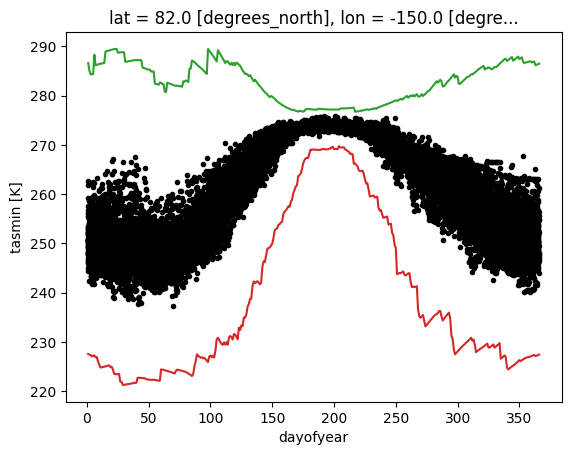

In [35]:
# Look at an example point that is outside the bounds of what is reasonable

plt.plot(pt_vals["time.dayofyear"], pt_vals, ".k")
plt.plot(pt_vals["time.dayofyear"], pt_vals.where(pt_too_high), "o", fillstyle="none")
plt.plot(pt_vals["time.dayofyear"], pt_vals.where(pt_too_low), "o", fillstyle="none")
# plt.plot(pt_vals['time.dayofyear'],pt_vals.where(pt_vals>high_bound.sel(lat=ilat,lon=ilon,method='nearest')),'o', fillstyle=None)
pt_bound_high.plot()
pt_bound_low.plot()

# Loop through a bunch of scenarios

In [36]:
var_list = ["tas", "tasmax", "tasmin", "tas", "tasmax", "tasmin", "tas", "tasmax", "tasmin"]
scenario_list = [
    "historical",
    "historical",
    "historical",
    "g6_1p5k",
    "g6_1p5k",
    "g6_1p5k",
    "ssp245",
    "ssp245",
    "ssp245",
]
ens_list = ["r3i1p1f1", "001", "001", "003", "003", "003", "008", "008", "008"]

######################################################
tas
historical
r3i1p1f1
######################################################
Fraction of area too high: 0.0
Fraction of area too low: 0.0
######################################################
tasmax
historical
001
######################################################
Fraction of area too high: 0.0
Fraction of area too low: 0.0
######################################################
tasmin
historical
001
######################################################
Fraction of area too high: 6.74217907227616e-06
Fraction of area too low: 1.9263368777931887e-06
######################################################
tas
g6_1p5k
003
######################################################
Fraction of area too high: 2.8895053166897826e-05
Fraction of area too low: 4.334257975034674e-05
######################################################
tasmax
g6_1p5k
003
######################################################



KeyboardInterrupt



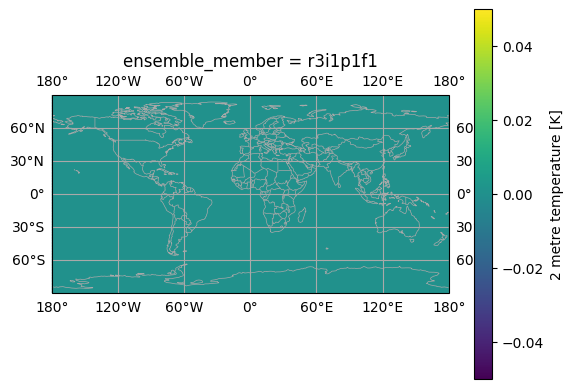

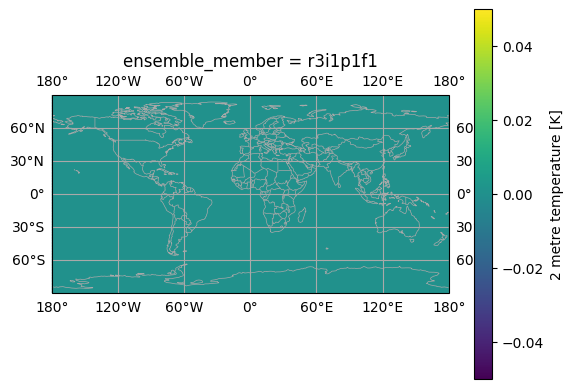

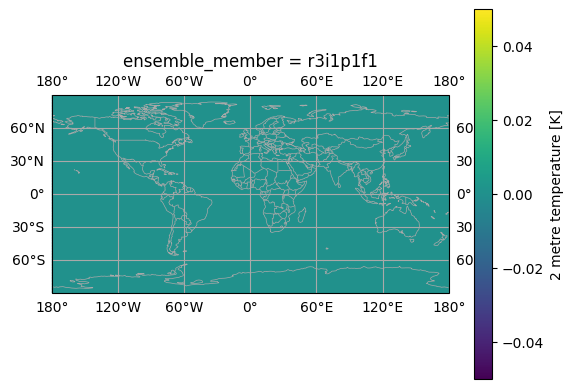

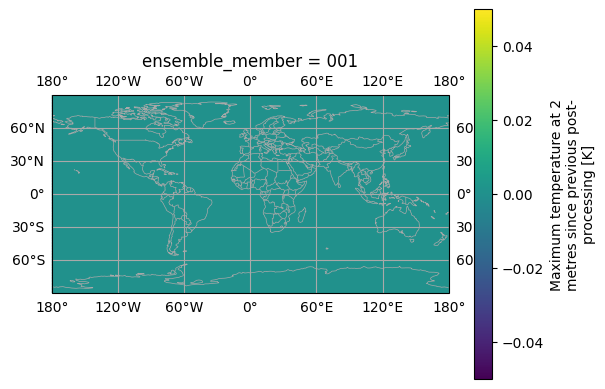

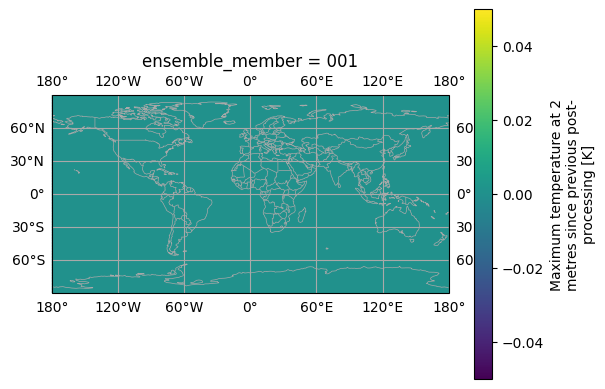

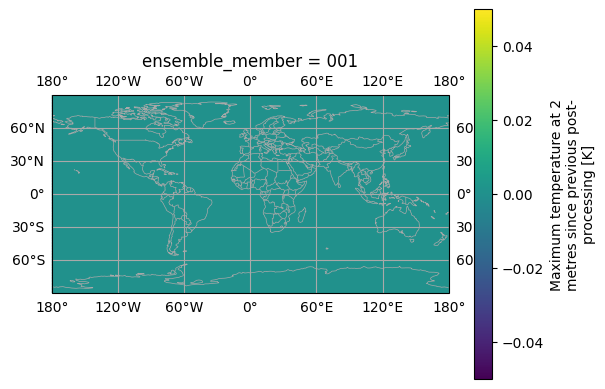

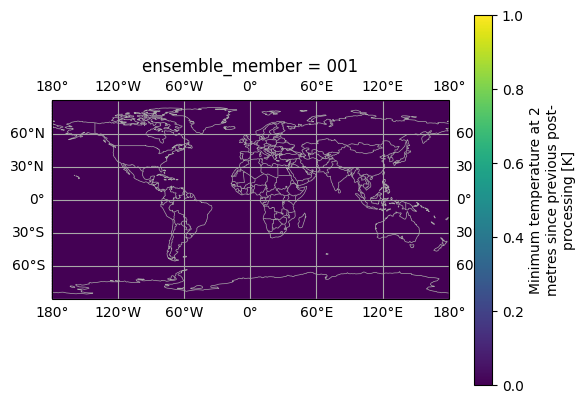

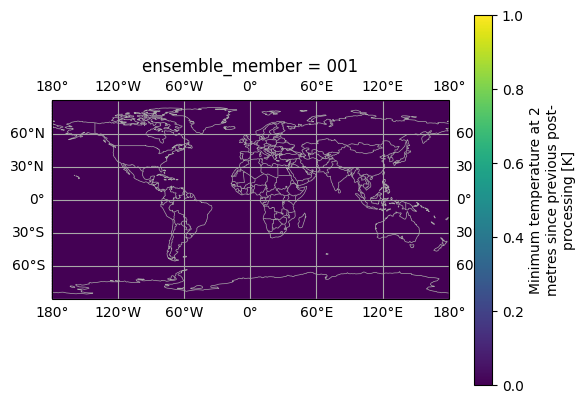

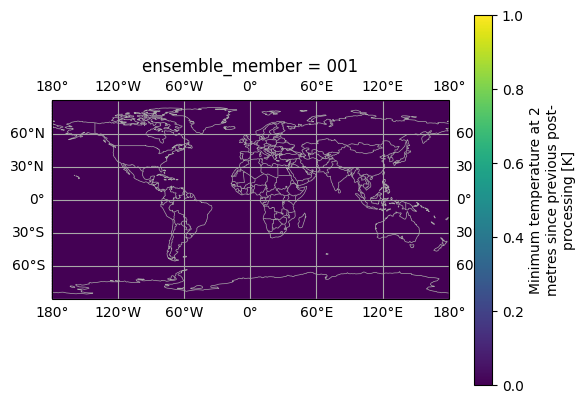

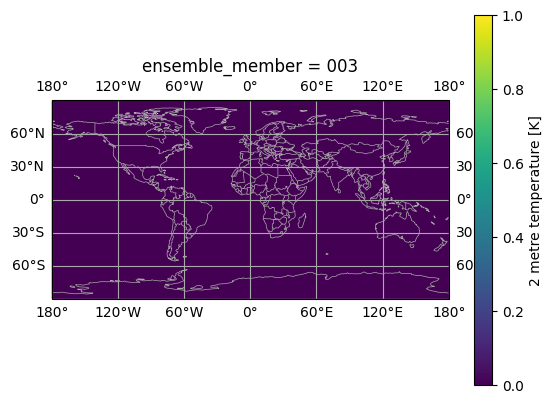

Error in callback <function flush_figures at 0xe3f01c4ec860> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



In [37]:
for i, var in enumerate(var_list):
    if i > 3:
        scenario = scenario_list[i]
        ens = ens_list[i]

        print("######################################################")
        print(var)
        print(scenario)
        print(ens)
        print("######################################################")

        debiased_downscaled = open_icechunk(
            path=path_output,
            branch=branch,
            group=scenario + "/" + var + "/" + ens,
        )[var]

        obs_fine = catalog.get("ERA5").to_xarray()[var]
        obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)

        raw_scenario = (
            catalog.get("CESM2-WACCM").to_xarray()[scenario][var].sel(ensemble_member=ens)
        )
        raw_historical = catalog.get("CESM2-WACCM").to_xarray()["historical"][var]

        if spatial_subset:
            obs_fine_subset = obs_fine.sel(lat=slice(-35, -22), lon=slice(16, 33))
            raw_scenario_subset = raw_scenario.sel(lat=slice(-35, -22), lon=slice(16, 33)).load()
            raw_historical_subset = raw_historical.sel(
                lat=slice(-35, -22), lon=slice(16, 33)
            ).load()
        else:
            obs_fine_subset = obs_fine
            raw_scenario_subset = raw_scenario
            raw_historical_subset = raw_historical

        low_bound, high_bound = calculate_reasonable_bounds_doy(
            raw_scenario_subset=raw_scenario_subset,
            raw_historical_subset=raw_historical_subset,
            obs_fine_subset=obs_fine_subset,
        )

        high_bound_generous = high_bound + 5
        low_bound_generous = low_bound - 5

        # Very slow step
        doy = debiased_downscaled["time.dayofyear"]
        too_high = (
            (debiased_downscaled > high_bound_generous.sel(dayofyear=doy))
            .mean(dim="time")
            .compute()
        )
        too_low = (
            (debiased_downscaled < low_bound_generous.sel(dayofyear=doy)).mean(dim="time").compute()
        )

        print_frac_implausible(
            too_high,
            too_low,
            variable=var,
            scenario=scenario,
            ensemble_member=ens,
            log_path=path_qaqc
            + "area_out_of_range_frac_"
            + var
            + "_"
            + scenario
            + "_"
            + ens
            + ".csv",
        )
        print(too_high.where(too_high > 0, drop=True))
        print(too_low.where(too_high > 0, drop=True))

        fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="darkgray")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="darkgray")

        ((too_high + too_low) > 0).plot(ax=ax, transform=ccrs.PlateCarree(), label="Outside bounds")

        ax.gridlines(draw_labels=True, color="darkgray")
        plt.savefig(path_qaqc + "map_out_of_range_" + var + "_" + scenario + "_" + ens + ".png")

        fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="darkgray")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="darkgray")

        (too_low > 0).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            label="How outside bounds",
        )

        ax.gridlines(draw_labels=True, color="darkgray")
        plt.savefig(path_qaqc + "map_min_out_of_range_" + var + "_" + scenario + "_" + ens + ".png")

        fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="darkgray")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="darkgray")

        (too_high > 0).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            label="How outside bounds",
        )

        ax.gridlines(draw_labels=True, color="darkgray")
        plt.savefig(path_qaqc + "map_max_out_of_range_" + var + "_" + scenario + "_" + ens + ".png")